In [5]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [7]:
# Read the dataset into a DataFrame
df = pd.read_csv("AB_NYC_2019.csv")
# Display the first 5 rows to get a quick overview of the data structure and column names
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
# Display a summary of the DataFrame including column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [10]:
#Print out the number of missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


# ———— Task 1: Data Cleaning ———— 
The dataset contains 48,895 entries with 16 columns. The following cleaning steps should be performed:
1. **Missing values in `name` and `host_name`**: A small number of rows (16 and 21 respectively) can be dropped as they represent an insignificant portion of the data.
2. **Missing values in `reviews_per_month`**: 10,052 entries were missing. These were filled with 0, since listings with no reviews naturally have zero reviews per month.
3. **Missing values in `last_review`**: Same 10,052 entries were missing, filled with 'Unknown' before converting to datetime format.
4. **Price anomalies**: Listings with a price of $0 have to be removed as they are invalid and would skew the analysis.
5. **Data type conversion**: `last_review` was converted from object to datetime to enable time-based analysis.

In [20]:
#1. Drop row where "name" or "host_name" is missing
df = df.dropna(subset=['name','host_name'])

#2. Fill missing 'reviews_per_month' with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

#3. Fill missing "last_review" with 'unknown'
df['last_review'] = df['last_review'].fillna('Unknown')

#4. Remove recordings with price = 0
df = df[df['price'] > 0]

#5. Covert 'last_review' to datetime for potential time-based analysis
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

#Confirm cleaning results
print(f"Remaining rows after cleaning {len(df)}")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Remaining rows after cleaning 48847

Missing values after cleaning:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10036
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [25]:
# ———— Task 2a: Top 5 and Bottom 5 neighborhoods by average price ———— 

#Calculate average price per neighborhood, only keep neighborhoods with more than 5 listings
neighborhood_price = df.groupby('neighbourhood').agg(
    avg_price=('price', 'mean'),
    count=('price','count')
).reset_index()

#Filter neighborhoods with more than 5 listings
neighborhood_price = neighborhood_price[neighborhood_price['count'] > 5]

#Sort by average price
neighborhood_price = neighborhood_price.sort_values('avg_price', ascending=False)

#Get top 5 and buttom 5
top5 = neighborhood_price.head(5)
bottom5 = neighborhood_price.tail(5)

print("Top 5 most expensive neighborhoods:")
print(top5[['neighbourhood','avg_price']])

print("\nBottom 5 least expensive neighborhoods:")
print(bottom[['neighbourhood','avg_price']])


Top 5 most expensive neighborhoods:
         neighbourhood   avg_price
197            Tribeca  490.638418
174           Sea Gate  487.857143
167          Riverdale  442.090909
6    Battery Park City  367.086957
75   Flatiron District  341.925000

Bottom 5 least expensive neighborhoods:
    neighbourhood  avg_price
24      Bronxdale  57.105263
179     Soundview  53.466667
196       Tremont  51.545455
102   Hunts Point  50.500000
27    Bull's Head  47.333333


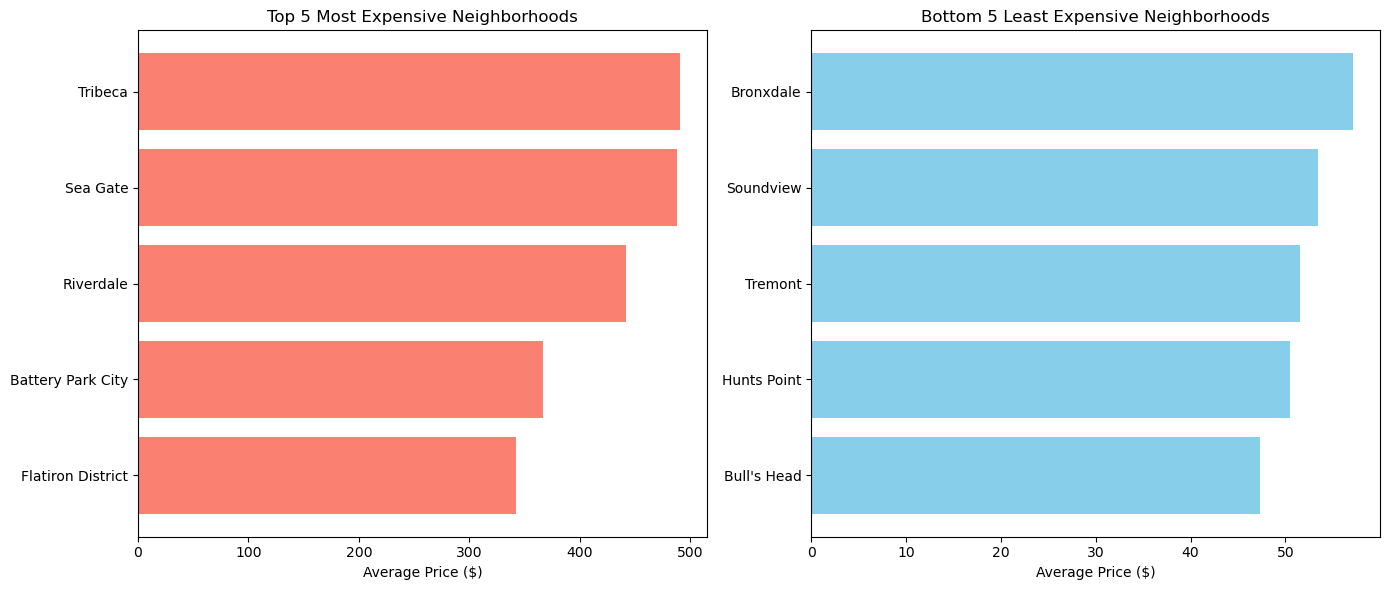

In [26]:
# ———— Task 2b:Analysis and data visulization ———— 
# Plot Top 5 and Bottom 5 neighborhoods
fig, axes = plt.subplots(1, 2, figsize=(14,6))

#Top 5
axes[0].barh(top5['neighbourhood'], top5['avg_price'], color = 'salmon')
axes[0].set_title('Top 5 Most Expensive Neighborhoods')
axes[0].set_xlabel('Average Price ($)')
axes[0].invert_yaxis()

#Bottom 5
axes[1].barh(bottom5['neighbourhood'], bottom5['avg_price'], color='skyblue')
axes[1].set_title('Bottom 5 Least Expensive Neighborhoods')
axes[1].set_xlabel('Average Price ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

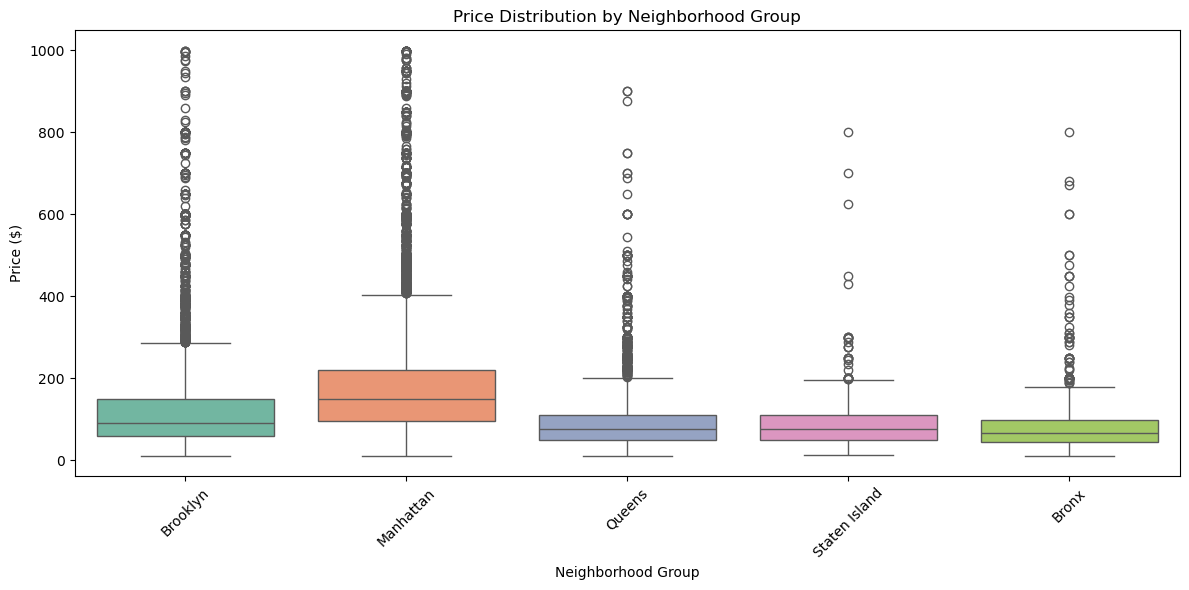

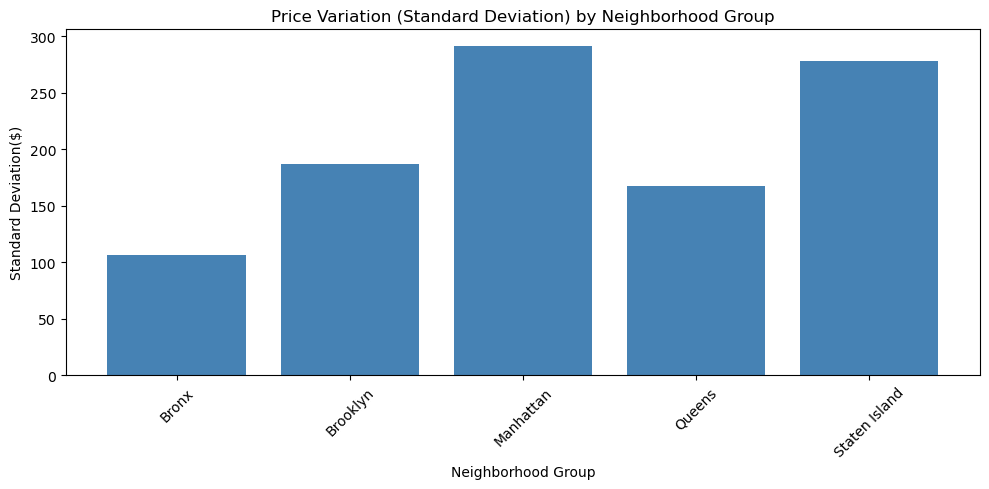

In [33]:
#Calculate mean and standard deviation of price per neighborhood group
price_stats = df.groupby('neighbourhood_group')['price'].agg(['mean', 'std']).reset_index()
price_stats.columns = ['neighbourhood_group', 'mean_price', 'std_price']

# Box plot to show price distribution and variation across neighborhood groups
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['price'] < 1000], x='neighbourhood_group', y='price', hue='neighbourhood_group', palette='Set2', legend=False)
plt.title('Price Distribution by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Bar plot showing average price per neighborhood group
plt.figure(figsize=(10, 5))
plt.bar(price_stats['neighbourhood_group'], price_stats['std_price'], color='steelblue')
plt.title('Price Variation (Standard Deviation) by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Standard Deviation($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [36]:
# ———— Task 3:Pairwise Pearson Coorelation Analysis ————

#Select the most interesting numerical features
features = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

#Calculate pairwise Pearson correlation
corr_matrix = df[features].corr(method='pearson')
print(corr_matrix)

                                   price  minimum_nights  number_of_reviews  \
price                           1.000000        0.042810          -0.047920   
minimum_nights                  0.042810        1.000000          -0.081573   
number_of_reviews              -0.047920       -0.081573           1.000000   
reviews_per_month              -0.050552       -0.127342           0.589125   
calculated_host_listings_count  0.057450        0.131315          -0.072417   
availability_365                0.081836        0.145924           0.171803   

                                reviews_per_month  \
price                                   -0.050552   
minimum_nights                          -0.127342   
number_of_reviews                        0.589125   
reviews_per_month                        1.000000   
calculated_host_listings_count          -0.047375   
availability_365                         0.163683   

                                calculated_host_listings_count  \
price   

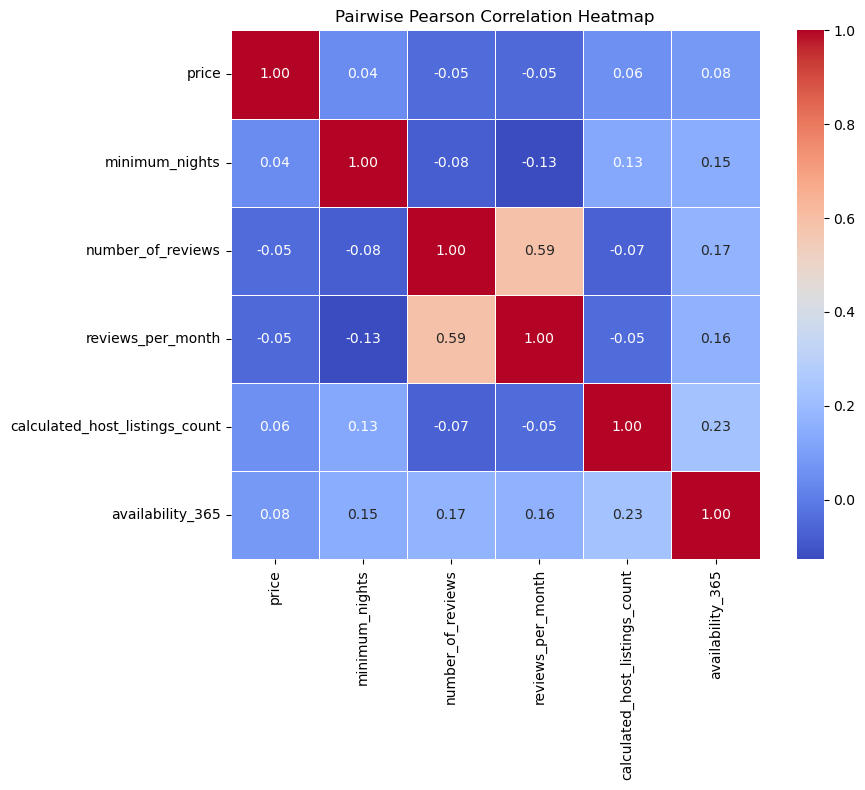

In [37]:
#Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Pairwise Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

In [38]:
#Find most positive and negative correlations
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.drop_duplicates()

print("Most positive correlation:")
print(corr_pairs.idxmax(), corr_pairs.max())

print("\nMost negative correlation:")
print(corr_pairs.idxmin(),corr_pairs.min())

Most positive correlation:
('number_of_reviews', 'reviews_per_month') 0.5891246914158204

Most negative correlation:
('minimum_nights', 'reviews_per_month') -0.12734217566034264


# ———— Task 3: Pearson Correlation Analysis ————

The following features were selected for correlation analysis:
- price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365

**Most positive correlation**: ('number_of_reviews', 'reviews_per_month') 0.5891246914158204
**Most negative correlation**: ('minimum_nights', 'reviews_per_month') -0.12734217566034264

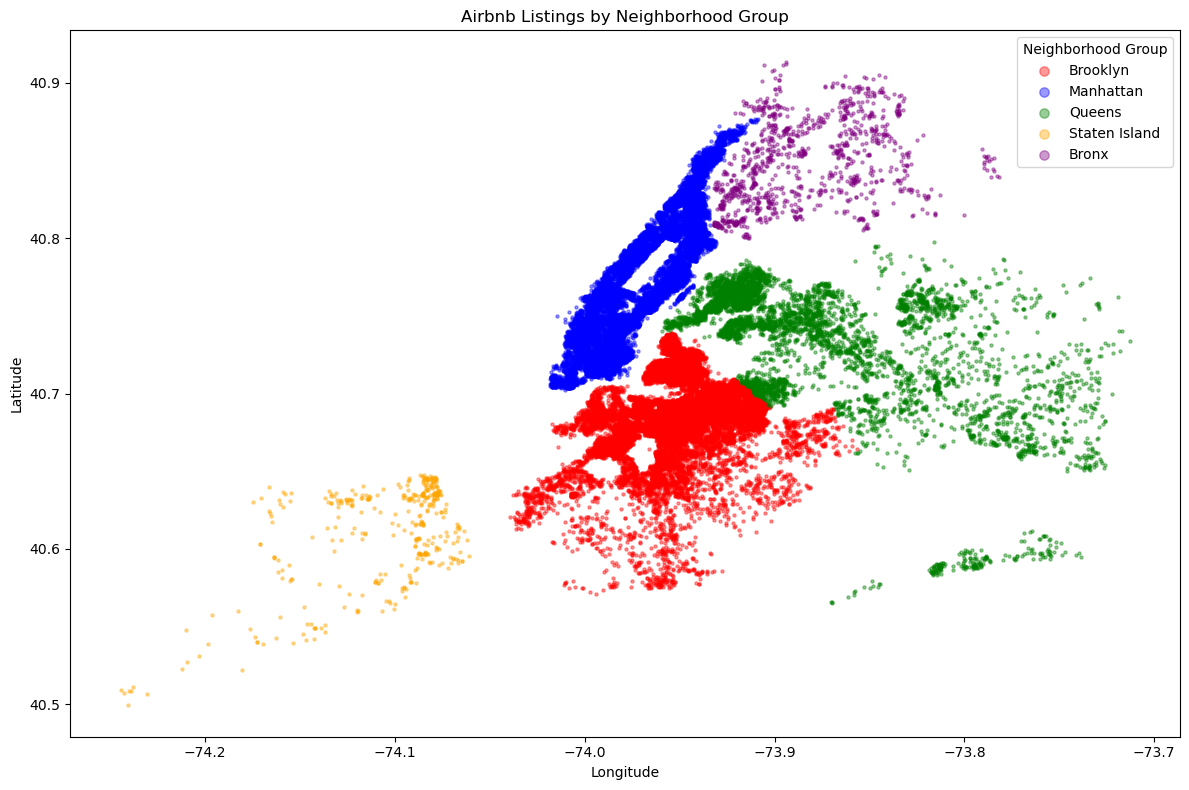

In [39]:
# ———— Task 4a: Scatter plot color coded by neighborhood group ————
plt.figure(figsize=(12,8))
#Get unique neighborhood groups and assign colors
neighborhood_groups = df['neighbourhood_group'].unique()
colors=['red','blue','green','orange','purple']

for group, color in zip(neighborhood_groups, colors):
    subset = df[df['neighbourhood_group'] == group]
    plt.scatter(subset['longitude'], subset['latitude'], c=color, label=group, alpha=0.4, s=5)

plt.title('Airbnb Listings by Neighborhood Group')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighborhood Group', markerscale=3)
plt.tight_layout()
plt.show()

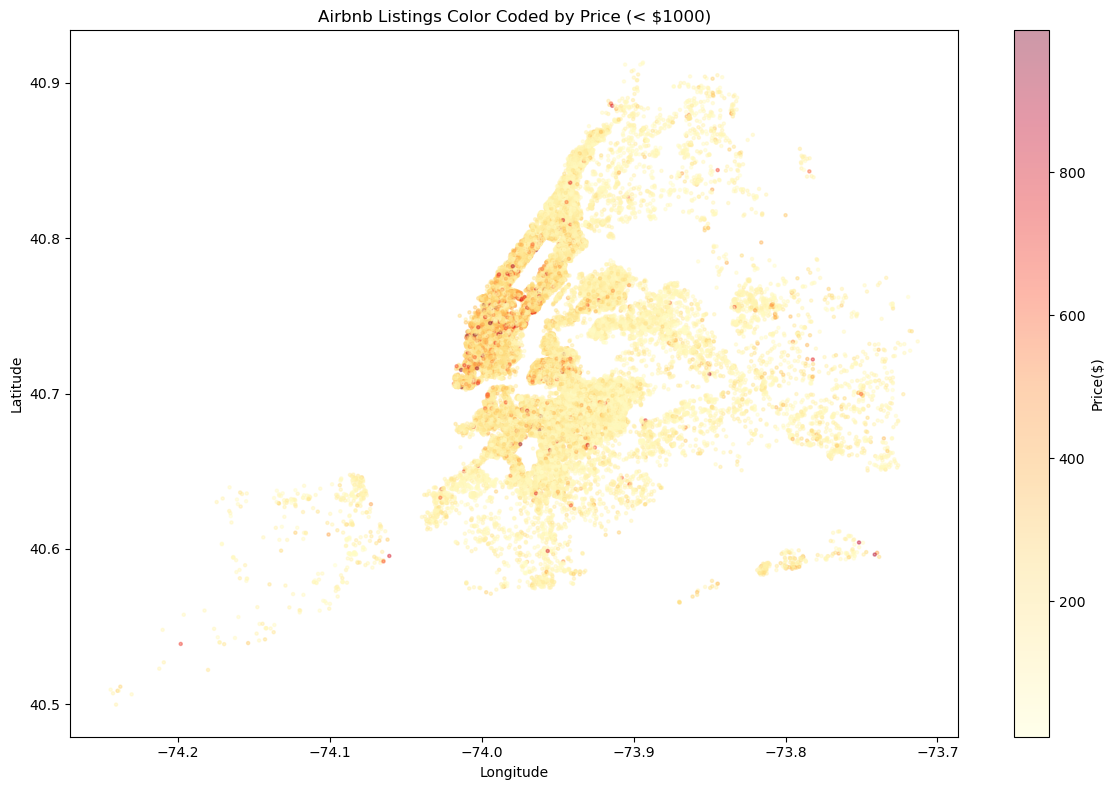

In [42]:
# ———— Task 4b: Scatter plot color coded by price(< 1000) ————
df_filtered=df[df['price'] < 1000]
plt.figure(figsize = (12,8))
scatter = plt.scatter(df_filtered['longitude'], df_filtered['latitude'], c=df_filtered['price'], cmap='YlOrRd', alpha=0.4, s=5)

plt.colorbar(scatter, label='Price($)')
plt.title('Airbnb Listings Color Coded by Price (< $1000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## Task 4b - Analysis

Looking at the scatter plot, the darkest colored points (highest price) are concentrated in the Manhattan area, which corresponds to the narrow vertical strip in the center-left of the map (latitude ~40.7–40.85, longitude ~-74.0 to -73.95). This suggests that **Manhattan is the most expensive neighborhood group**, which aligns with its reputation as the most commercially dense and desirable borough in New York City.

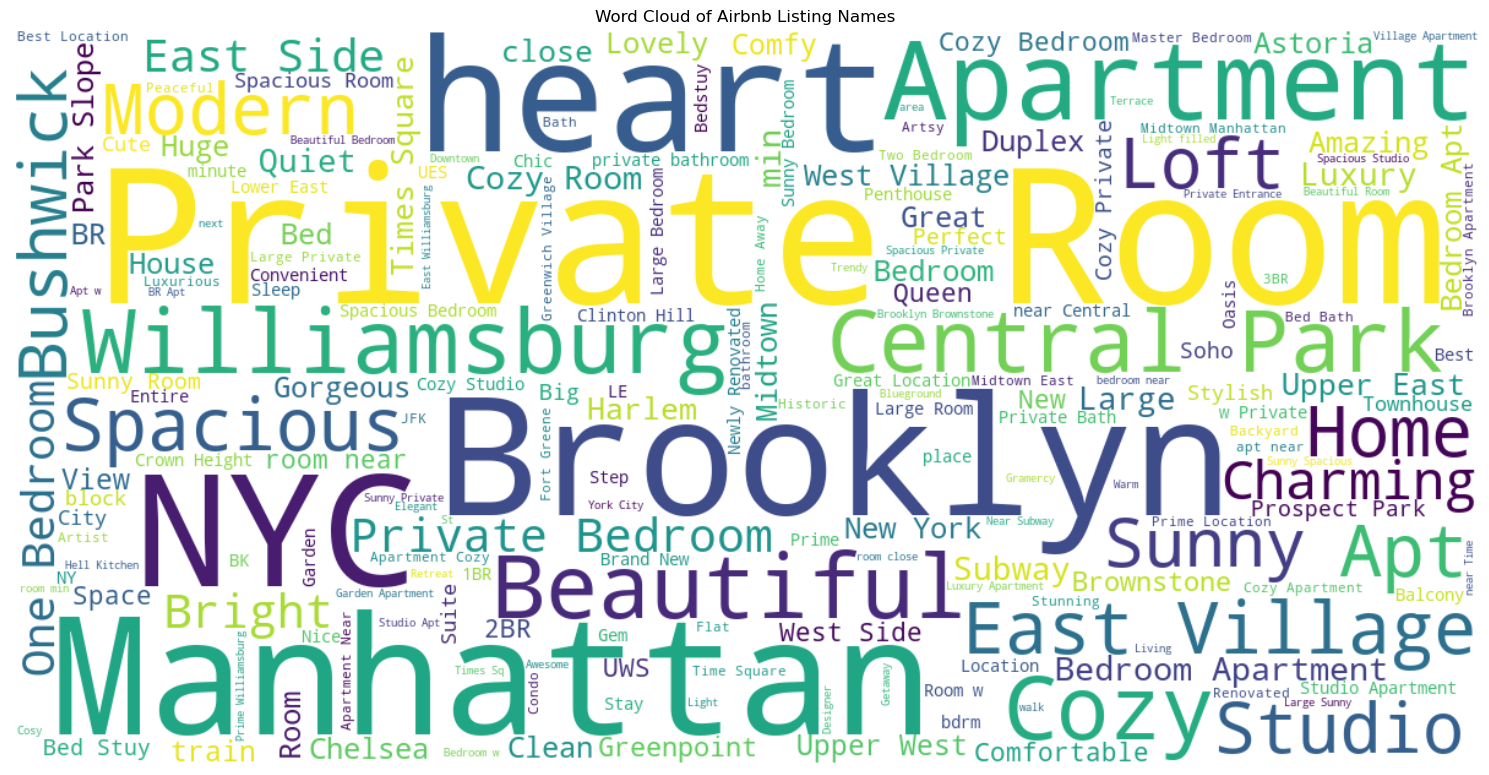

In [45]:
# ———— Task 5: Word Cloud from Airbnb listing names ————

#Combine all listing names into one string, drop missing values
text = ' '.join(df['name'].dropna().values)

#Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=200
).generate(text)

#Plot the word cloud
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Airbnb Listing Names')
plt.tight_layout()
plt.show()

In [47]:
# ———— Task 6: Busiest Hosts Analysis ————

#Find top 10 busiest hosts by number of listings
busiest_hosts = df.groupby(['host_id', 'host_name', 'neighbourhood_group']).agg(
    listing_count=('id', 'count'),
    avg_price=('price','mean'),
    avg_availability=('availability_365','mean'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_reviews_per_month=('reviews_per_month', 'mean'),
).reset_index().sort_values('listing_count', ascending=False).head(10)

print("Top 10 Busiest Hosts: ")
print(busiest_hosts[['host_name', 'neighbourhood_group', 'listing_count', 'avg_price', 'avg_availability', 'avg_reviews']])

Top 10 Busiest Hosts: 
               host_name neighbourhood_group  listing_count   avg_price  \
34724       Sonder (NYC)           Manhattan            327  253.195719   
29465         Blueground           Manhattan            230  303.221739   
19617               Kara           Manhattan            121  277.528926   
12835             Sonder           Manhattan             96  213.031250   
14470     Jeremy & Laura           Manhattan             96  208.958333   
25716  Corporate Housing           Manhattan             91  146.241758   
17135                Ken           Manhattan             86  215.593023   
31143             Kazuya              Queens             79   43.924051   
33942            Pranjal           Manhattan             65  290.230769   
9750                Vida            Brooklyn             52  149.192308   

       avg_availability  avg_reviews  
34724        301.492355     3.917431  
29465        253.682609     0.126087  
19617        313.421488     0.5371

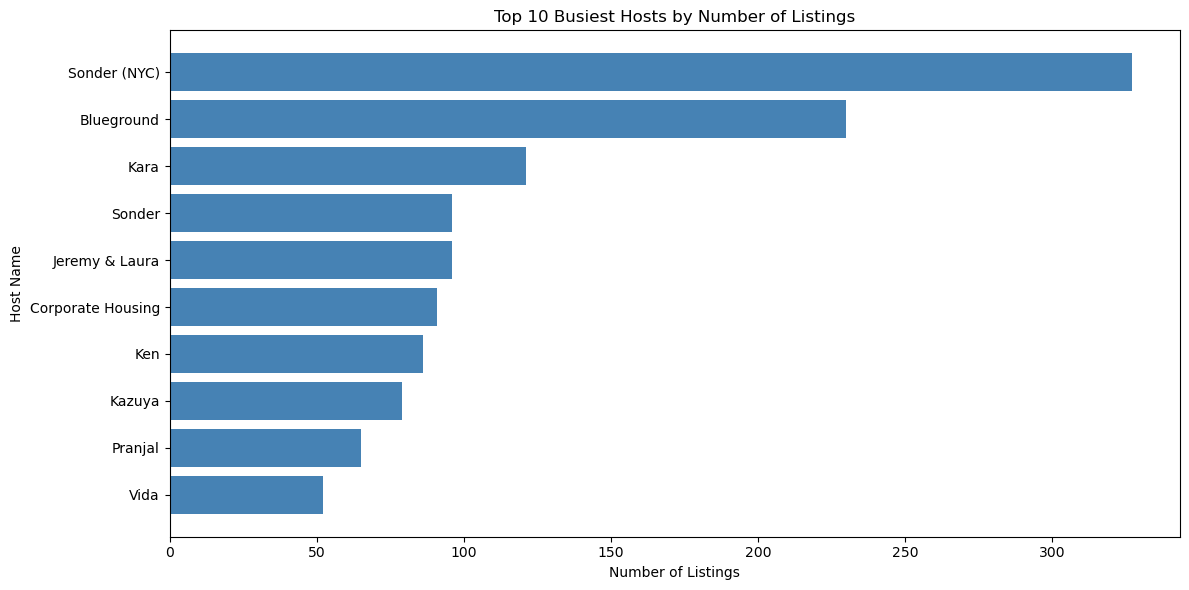

In [48]:
# Bar plot: Top 10 busiest hosts by listing count
plt.figure(figsize=(12,6))
plt.barh(busiest_hosts['host_name'], busiest_hosts['listing_count'], color='steelblue')
plt.title('Top 10 Busiest Hosts by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Host Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

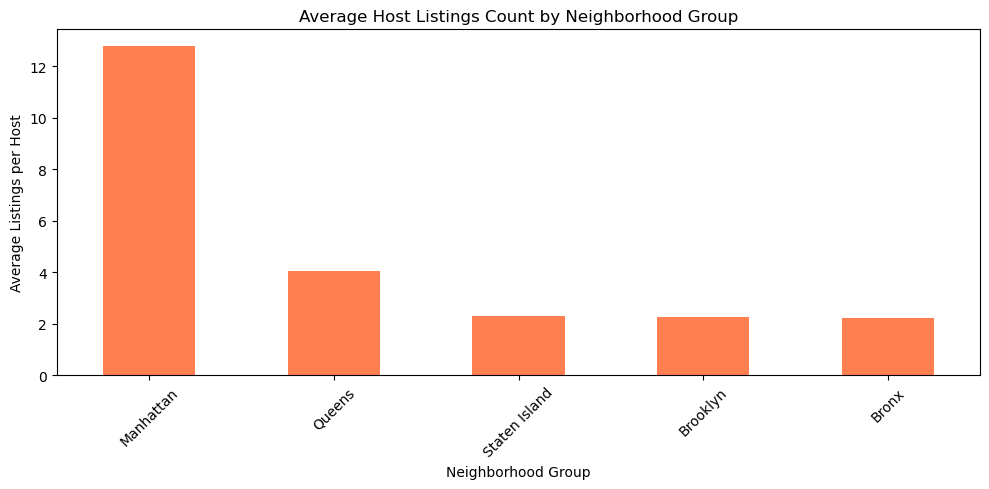

In [51]:
#Find the neighborhood group which has the most busiest hosts
area_busiest = df.groupby('neighbourhood_group')['calculated_host_listings_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
area_busiest.plot(kind='bar', color='coral')
plt.title('Average Host Listings Count by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Listings per Host')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

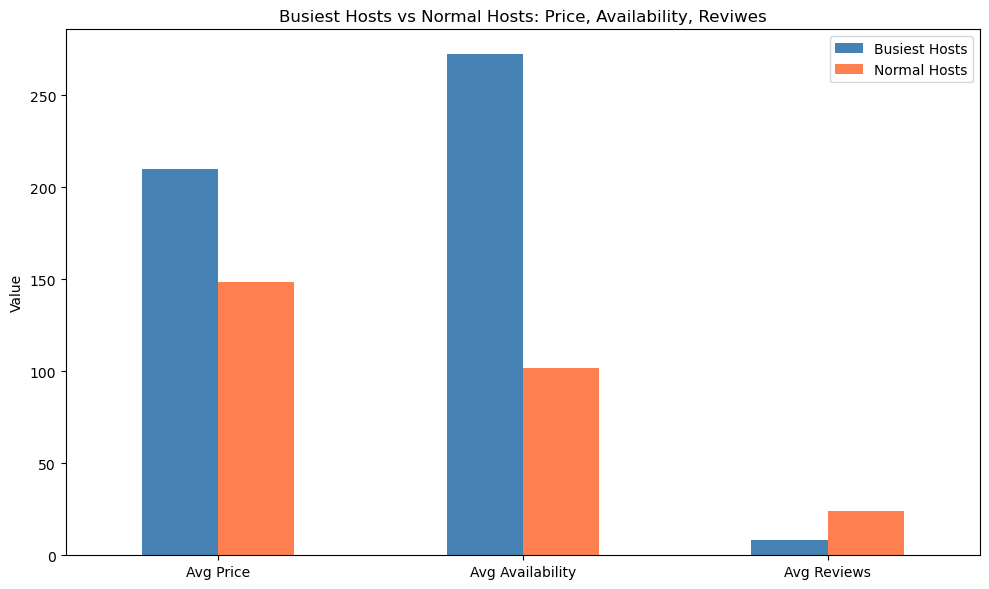

In [54]:
# Compare busiest hosts vs average hosts: price, availability, reviews
busy_hosts = df[df['calculated_host_listings_count'] >= 10]
normal_hosts = df[df['calculated_host_listings_count'] < 10]

comparison = pd.DataFrame({
    'Busiest Hosts': [busy_hosts['price'].mean(), busy_hosts['availability_365'].mean(), busy_hosts['number_of_reviews'].mean()],
    'Normal Hosts': [normal_hosts['price'].mean(), normal_hosts['availability_365'].mean(), normal_hosts['number_of_reviews'].mean()]
}, index=['Avg Price', 'Avg Availability', 'Avg Reviews'])

comparison.plot(kind='bar',figsize=(10,6), color=['steelblue', 'coral'])
plt.title('Busiest Hosts vs Normal Hosts: Price, Availability, Reviwes')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

#Task 6 - Analysis

The busiest hosts are primarily concentrated in Manhattan, which is the most commercially active borough in New York City.

Comparing busiest hosts vs normal hosts reveals three key findings:

1. **Higher Price**: Busiest hosts charge an average of ~$210 per night compared to ~$150 for normal hosts. This suggests that busiest hosts manage higher-end properties, possibly because they operate as professional property managers with premium listings
2. **Much Higher Availability**: Busiest hosts have an average availability of  ~270 days per year, compared to only ~100 days for normal hosts. This is a major reason why they are the busiest: their listings are available almost year-round, giving guests more opportunity to book them.
3. **Fewer Reviews**: Busiest hosts have fewer average reviews (~10) compared to normal hosts (~25). This may be because their listings are spread across many properties, so each individual listing accumulates fewer reviews, even though the host overall is very active.

In conclusion, the busiest hosts tend to be professional property managers who maintain high availability and charge premium prices, rather than individual hosts renting out a single room occasionally.

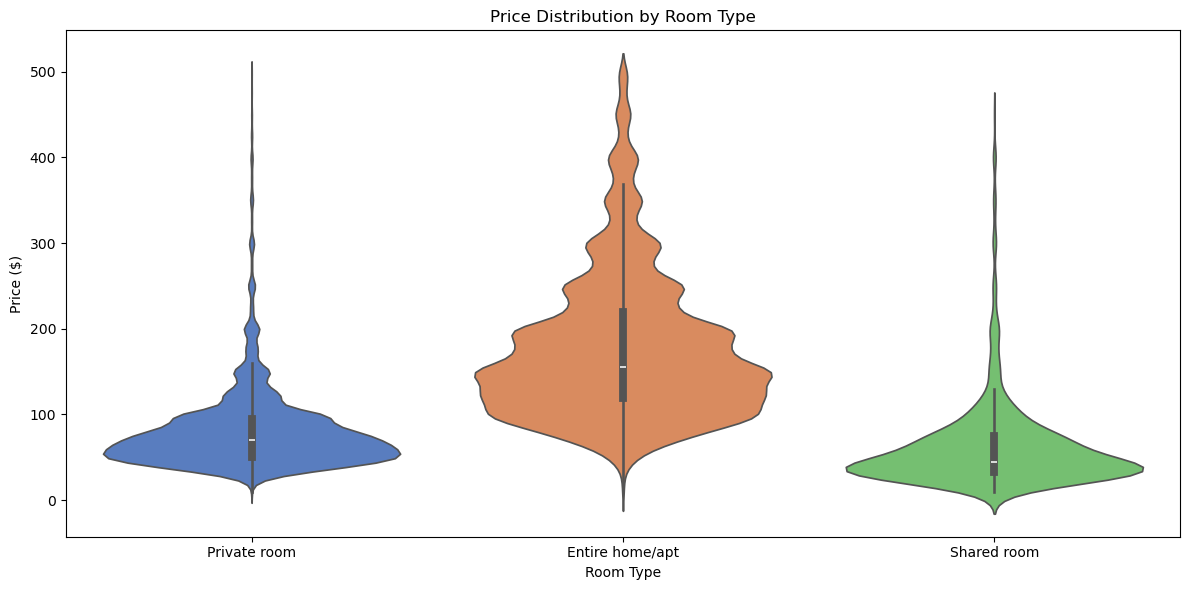

In [56]:
# ———— Task 7: Custom Plots ————

#Plot 1: Violin plot - Price distribution by room type (<500)
plt.figure(figsize=(12,6))
sns.violinplot(data=df[df['price'] < 500], x='room_type', y='price', hue='room_type', palette='muted', legend=False)
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

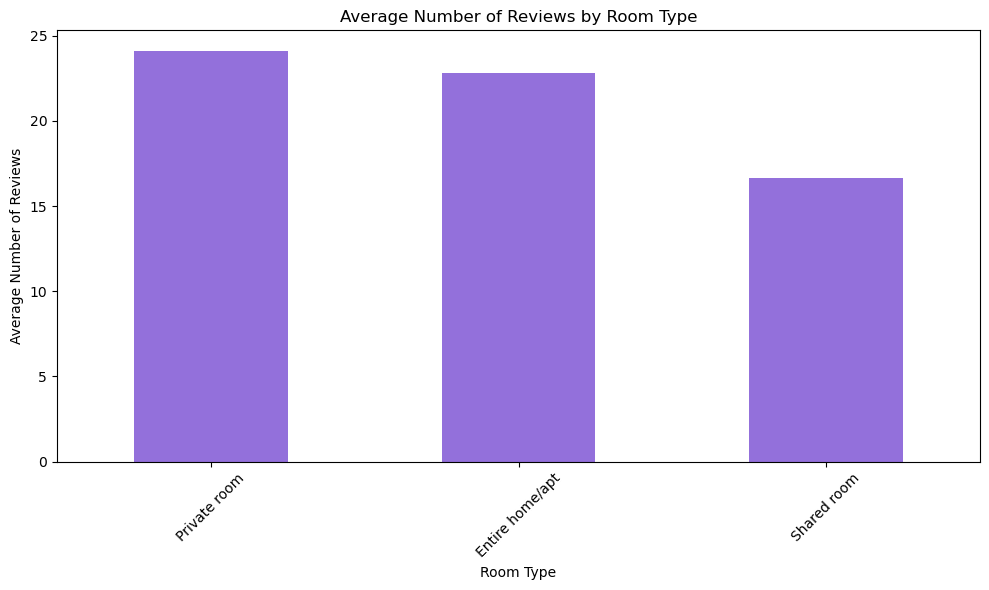

In [57]:
#Plot 2: Average number of reviews by room type
avg_reviews_by_room = df.groupby('room_type')['number_of_reviews'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_reviews_by_room.plot(kind='bar', color='mediumpurple')
plt.title('Average Number of Reviews by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 7 - Custom Plots Analysis
## Plot 1: Price Distribution by Room Type

The violin plot reveals that Entire home/apt listings have the widest price distribution, with prices spreading from near $0 all the way to $500+, and a median around $150. Private rooms are much more affordable with most prices clustered around $60-$$70. Shared rooms are the cheapest option, which prices concentrated below $50. This makes intuitive sense that renting an entire apartment gives guests full privacy and space, justifying a higher price, which shared rooms offer the least privacy and are priced accordingly.

## Plot 2: Average Number of Reviews by Room Type

Interestingly, Private rooms have the highest average number of reviews, slightly more than Entire home/apt, while Shared rooms have the fewest. This is surprising because Entire home/apt listings are the most expensive so people might expect them to have more reviews due to higher demand. However, this suggests that Private rooms may attract more frequent short-term travelers who are more likely to leave reviews, while Entire home/apt guests may stay longer and review less often. 